In [2]:
import torch
from torch.nn import functional as F

import numpy as np
import voxeloo

from PIL import Image
from dataclasses import dataclass
from typing import Optional

from perlin_numpy import (
    generate_fractal_noise_2d, generate_fractal_noise_3d,
    generate_perlin_noise_2d, generate_perlin_noise_3d
)

In [3]:
points = np.stack(
    np.meshgrid(
        np.linspace(0, 512, 16),
        np.linspace(0, 512, 16),
    ),
    axis=-1,
)

In [4]:
points += 24.0 * np.random.random(points.shape)

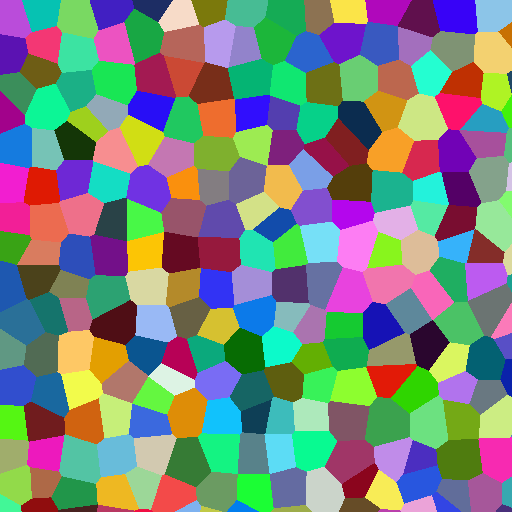

In [5]:
image = voxeloo.voronoi.rasterize_2d(points.reshape(-1, 2).astype(int), (512, 512))
palette = np.random.randint(0, 255, size=(image.max() + 1, 3), dtype=np.uint8)
Image.fromarray(palette[image])

In [6]:
# 1. Assign tiles to height classes.
# 2. Generate a "mask" for each tile class.

In [7]:
def heatmap_to_image(heat):
    return Image.fromarray(np.uint8(heat * 255) , "L")

In [8]:
noise = generate_fractal_noise_2d(
    shape=(512, 512),
    res=(8, 8),
    octaves=4,
    persistence=0.3,
    lacunarity=2,
)

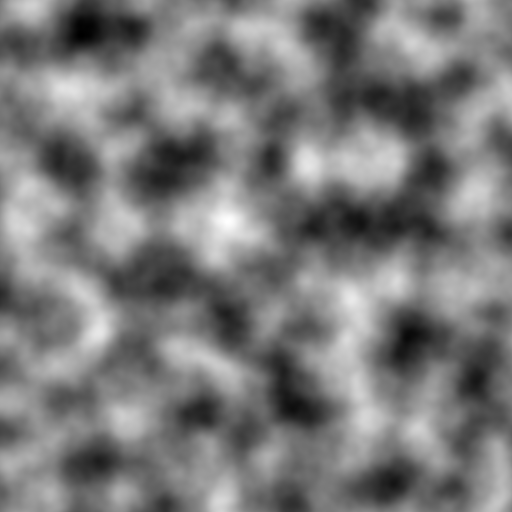

In [9]:
heatmap_to_image((noise - noise.min()) / (noise.max() - noise.min()))